# Getting started with terrastat

`terrastat` gathers public economic time series from **FRED**, **Eurostat** and **OECD** into a tidy,
licence-aware Parquet database, politely (one connection per source, paced) and resumably.
This notebook walks through the whole process on a few small datasets so you can see every file
it produces. Re-run it whenever you want to refresh your view of the data: every step reuses what
is already on disk and only downloads what is missing.

Four layers, each usable while the next is still being built:

| layer | where | shape | for |
|---|---|---|---|
| raw | `data/raw/<source>/<dataset>/` | payload exactly as served | reproducibility |
| datasets | `data/datasets/<source>/<dataset>/` | `observations.parquet` (one row per observation) + `dataset.json` | tables: pandas, DuckDB, R |
| series | `data/series/<source>/freq=<F>/` | one row per series, lists of dates and values, metadata as text | models |
| snapshot | `data/snapshot/<name>/` | fixed-size shuffled shards + index + manifest | training |

Run this notebook from the `terrastat` environment: `.\.venv\Scripts\jupyter lab` in the `terrastat` folder
(or `jupyter lab` after activation). The [manual](../MANUAL.md) explains the command line; the
[README](../README.md) is the technical reference.

In [1]:
import json, os
from pathlib import Path
import polars as pl, pandas as pd, duckdb
import matplotlib.pyplot as plt

import terrastat
from terrastat.config import data_dir
from terrastat import pipeline
from terrastat.series import build_series, SERIES_SCHEMA
from terrastat.export import export_shards, iter_shard_batches
from terrastat.storage import dataset_dir

pl.Config.set_fmt_str_lengths(60); pl.Config.set_tbl_width_chars(160); pl.Config.set_tbl_rows(12)
print("terrastat", terrastat.__version__, "| data directory:", data_dir())
print("FRED key present:", bool(os.getenv("FRED_API_KEY")))

terrastat 0.1.0 | data directory: C:\postdoc\econ_world_model\terrastat\data
FRED key present: True


## 1. What each source offers: the catalogue

The catalogue is downloaded once per source and cached (`data/catalog/<source>.parquet`). It lists every
release (FRED), dataset (Eurostat) or dataflow (OECD) with a size hint and, for Eurostat, the frequencies
known before anything is downloaded.

In [2]:
for src in ("fred", "eurostat", "oecd"):
    cat = pipeline.load_catalog(src)          # cached; refresh=True re-downloads
    print(f"{src}: {cat.height} entries")
cat = pipeline.load_catalog("eurostat").with_columns(pl.col("extra").str.json_path_match("$.type").alias("type"))
datasets = cat.filter(pl.col("type") == "dataset")
pl.concat([
    datasets.filter(pl.col("frequencies").list.contains(f)).select(
        pl.lit(f).alias("frequency"), pl.len().alias("datasets"), pl.col("n_values").sum().alias("stored_values"))
    for f in ["M", "Q", "A", "S", "W", "D"]
])

fred: 331 entries
eurostat: 7570 entries
oecd: 1543 entries


frequency,datasets,stored_values
str,u32,i64
"""M""",226,1010454724
"""Q""",420,1126533482
"""A""",6154,4422403923
"""S""",19,453623
"""W""",14,224988092
"""D""",5,12880480


In [3]:
datasets.select("dataset_id", "title", "frequencies", "n_values", "last_updated").sort("n_values", descending=True).head(8)

dataset_id,title,frequencies,n_values,last_updated
str,str,list[str],i64,str
"""migr_asyrescra""","""Resettled persons by age, sex, citizenship and country of pr…","[""A""]",213650346,"""02.06.2026"""
"""hlth_cd_yro""","""Causes of death - deaths by NUTS 2 region of residence and o…","[""A""]",136120337,"""01.06.2026"""
"""migr_asyappctzm""","""Asylum applicants by type, citizenship, age and sex - monthl…","[""M""]",103462328,"""02.09.2026"""
"""proj_19rp3""","""Population on 1st January by age, sex, type of projection an…","[""A""]",91535616,"""23.04.2021"""
"""migr_asydcfstq""","""First instance decisions on applications by type of decision…","[""Q""]",91165960,"""28.08.2026"""
"""migr_asywithm""","""Asylum applications withdrawn by citizenship, age, sex and t…","[""M""]",88885613,"""02.09.2026"""
"""demo_r_mweek3""","""Deaths by week, sex, 5-year age group and NUTS 3 region""","[""W""]",84117913,"""28.08.2026"""
"""migr_eirtn1""","""Third-country nationals returned following an order to leave…","[""Q""]",77782771,"""03.09.2026"""


## 2. Fetch a few small datasets

`run_fetch` walks a list of datasets one at a time, paced, and records each finished one in
`data/state/<source>.jsonl`, so running this cell again skips them (pass `force=True` to redo).
The same thing from the command line is `terrastat fetch eurostat --ids irt_st_m`.

In [4]:
picks = {"eurostat": ["irt_st_m", "isoc_r_iumd_i"], "fred": ["10"], "oecd": ["OECD.TAD.ARP__DSD_FISH_PROD_DF_FISH_INLAND__1.0"]}
for src, ids in picks.items():
    refs = pipeline.select_refs(src, pipeline.load_catalog(src), ids=ids)
    print(src, pipeline.run_fetch(src, refs))

eurostat {'done': 0, 'raw': 0, 'failed': 0, 'skipped': 2, 'series': 0, 'observations': 0, 'stopped_early': False}
fred {'done': 0, 'raw': 0, 'failed': 0, 'skipped': 1, 'series': 0, 'observations': 0, 'stopped_early': False}
oecd {'done': 0, 'raw': 0, 'failed': 0, 'skipped': 1, 'series': 0, 'observations': 0, 'stopped_early': False}


In [5]:
for src in picks:
    st = pipeline.status(src)
    print(src, {k: st[k] for k in ("done", "raw_only", "failed", "series", "observations")})

eurostat {'done': 5602, 'raw_only': 0, 'failed': 8, 'series': 141010571, 'observations': 407027980}
fred {'done': 331, 'raw_only': 0, 'failed': 0, 'series': 845518, 'observations': 145505367}
oecd {'done': 581, 'raw_only': 0, 'failed': 32, 'series': 39807092, 'observations': 535721274}


## 3. Layer 1: one folder per dataset

`dataset.json` holds every piece of metadata the source gives: title, licence and the exact attribution
text, links to the methodology pages, and for SDMX sources every dimension with its code-to-label map.
`observations.parquet` is the compact long table: `series_key`, one column per dimension (codes),
`period`, `date`, `value`, `flag`.

In [6]:
d = dataset_dir("eurostat", "irt_st_m")
meta = json.load(open(d / "dataset.json", encoding="utf-8"))
print({k: meta[k] for k in ("title", "frequencies", "time_start", "time_end", "n_series", "n_obs", "last_updated", "retrieved_at")})
print(meta["license"]["attribution"])
pl.DataFrame([{"dimension": dm["id"], "name": dm["name"], "codes": len(dm["codes"]),
               "example": " | ".join(f"{k}={v}" for k, v in list(dm["codes"].items())[:3])} for dm in meta["dimensions"]])

{'title': 'Money market interest rates - monthly data', 'frequencies': ['M'], 'time_start': '1970-01-01', 'time_end': '2026-07-01', 'n_series': 64, 'n_obs': 22375, 'last_updated': '13.08.2026', 'retrieved_at': '2026-09-04T07:09:10+00:00'}
Source: Eurostat, dataset irt_st_m (Money market interest rates - monthly data), https://ec.europa.eu/eurostat/databrowser/view/irt_st_m/default/table, accessed 2026-09-04


dimension,name,codes,example
str,str,i64,str
"""freq""","""Time frequency""",1,"""M=Monthly"""
"""int_rt""","""Interest rate""",5,"""IRT_DTD=Day-to-day rate | IRT_M1=1-month rate | IRT_M12=12-m…"
"""geo""","""Geopolitical entity (reporting)""",16,"""BG=Bulgaria | CZ=Czechia | DK=Denmark"""


In [7]:
obs = pl.read_parquet(d / "observations.parquet")
print(obs.shape)
obs.head(6)

(22375, 8)


series_key,freq,int_rt,geo,period,date,value,flag
str,str,str,str,str,date,f64,str
"""M.IRT_DTD.BG""","""M""","""IRT_DTD""","""BG""","""1995-01""",1995-01-01,76.05,null
"""M.IRT_DTD.BG""","""M""","""IRT_DTD""","""BG""","""1995-02""",1995-02-01,75.43,null
"""M.IRT_DTD.BG""","""M""","""IRT_DTD""","""BG""","""1995-03""",1995-03-01,75.48,null
"""M.IRT_DTD.BG""","""M""","""IRT_DTD""","""BG""","""1995-04""",1995-04-01,67.88,null
"""M.IRT_DTD.BG""","""M""","""IRT_DTD""","""BG""","""1995-05""",1995-05-01,58.43,null
"""M.IRT_DTD.BG""","""M""","""IRT_DTD""","""BG""","""1995-06""",1995-06-01,54.08,null


In [8]:
# flags are kept, with their meaning
print({a["id"]: a["codes"] for a in meta["attributes"]})
obs.group_by("flag").len().sort("len", descending=True)

{'flag': {'b': 'break in time series', 'd': 'definition differs (see metadata)', 'm': 'missing value; data cannot exist'}}


flag,len
str,u32
null,21208
"""m""",1157
"""b""",7
"""d""",3


In [9]:
# FRED keeps per-series metadata next to the observations
fred_series = pl.read_parquet(dataset_dir("fred", "10") / "series.parquet")
fred_series.select("series_id", "title", "frequency", "units", "seasonal_adjustment", "copyright_id", "n_obs", "obs_start", "obs_end").head(6)

series_id,title,frequency,units,seasonal_adjustment,copyright_id,n_obs,obs_start,obs_end
str,str,str,str,str,str,i64,str,str
"""CPIAPPNS""","""Consumer Price Index for All Urban Consumers: Apparel in U.S…","""M""","""Index 1982-1984=100""","""Not Seasonally Adjusted""","""public domain: citation requested""",1096,"""1914-12-01""","""2026-07-01"""
"""CPIAPPSL""","""Consumer Price Index for All Urban Consumers: Apparel in U.S…","""M""","""Index 1982-1984=100""","""Seasonally Adjusted""","""public domain: citation requested""",954,"""1947-01-01""","""2026-07-01"""
"""CPIAUCNS""","""Consumer Price Index for All Urban Consumers: All Items in U…","""M""","""Index 1982-1984=100""","""Not Seasonally Adjusted""","""public domain: citation requested""",1362,"""1913-01-01""","""2026-07-01"""
"""CPIAUCSL""","""Consumer Price Index for All Urban Consumers: All Items in U…","""M""","""Index 1982-1984=100""","""Seasonally Adjusted""","""public domain: citation requested""",954,"""1947-01-01""","""2026-07-01"""
"""CPIEDUNS""","""Consumer Price Index for All Urban Consumers: Education and …","""M""","""Index Dec 1997=100""","""Not Seasonally Adjusted""","""public domain: citation requested""",402,"""1993-01-01""","""2026-07-01"""
"""CPIEDUSL""","""Consumer Price Index for All Urban Consumers: Education and …","""M""","""Index Dec 1997=100""","""Seasonally Adjusted""","""public domain: citation requested""",402,"""1993-01-01""","""2026-07-01"""


## 4. Layer 2: one row per series

Built from layer 1 without touching the network. Every source produces the same columns, so the whole
`data/series/` tree opens as one table. The three lists `dates`, `values`, `flags` have `n_points`
elements each; `description` is one sentence with all the metadata, ready for a text encoder.

FRED rows also carry the analyst **tags** once `terrastat tags fred` (or a complete `run`) has fetched
them: `tags` holds the names, and `description` adds "It is associated with the tags: ..." with the tag
notes spelled out, as in the reference project. Three tag groups (copyright status, seasonal adjustment,
frequency) are always present because they follow from the metadata.

In [10]:
for src in picks:
    print(src, build_series(src, min_obs=1))      # skips datasets already built
series = pl.scan_parquet(str(data_dir() / "series" / "**" / "*.parquet"))
series.group_by("source", "frequency").agg(pl.len().alias("series"), pl.col("n_points").sum().alias("points")).sort("source", "frequency").collect()

eurostat series: 100%|██████████| 5607/5607 [02:00<00:00, 46.58dataset/s]


eurostat {'datasets': 0, 'files': 0, 'skipped': 5607, 'failed': 0}


fred series: 100%|██████████| 331/331 [00:03<00:00, 97.78dataset/s]


fred {'datasets': 0, 'files': 0, 'skipped': 331, 'failed': 0}


oecd series: 100%|██████████| 581/581 [00:02<00:00, 218.99dataset/s]


oecd {'datasets': 0, 'files': 0, 'skipped': 581, 'failed': 0}


source,frequency,series,points
str,str,u32,i64
"""eurostat""","""A""",116640737,330981284
"""eurostat""","""D""",281,838299
"""eurostat""","""M""",129371,14197954
"""eurostat""","""OTHER""",526,526
"""eurostat""","""Q""",1624921,21603024
"""eurostat""","""S""",19301,459356
…,…,…,…
"""oecd""","""A""",31117219,459433885
"""oecd""","""A3""",735095,2114817


In [11]:
print(list(SERIES_SCHEMA))
cpi = series.filter(pl.col("series_uid") == "fred:CPIAUCSL").collect().row(0, named=True)
for k in ("series_uid", "title", "description", "frequency", "units", "license_id", "origin_us_federal", "attribution", "start_date", "end_date", "n_points"):
    print(f"{k:18s} {cpi[k]}")

['series_uid', 'source', 'source_id', 'dataset_id', 'dataset_title', 'title', 'description', 'frequency', 'frequency_raw', 'units', 'seasonal_adjustment', 'geo', 'geo_label', 'dimensions', 'tags', 'notes', 'license_id', 'license_name', 'license_url', 'license_detail', 'attribution', 'license_notes', 'origin_agencies', 'origin_us_federal', 'source_url', 'last_updated', 'retrieved_at', 'vintage', 'start_date', 'end_date', 'n_points', 'n_obs', 'n_flagged', 'dates', 'values', 'flags']
series_uid         fred:CPIAUCSL
title              Consumer Price Index for All Urban Consumers: All Items in U.S. City Average
description        Time series about Consumer Price Index for All Urban Consumers: All Items in U.S. City Average. It is associated with the tags: all items, average, consumer, Consumer Price Index, headline figure, indexes, inflation, nation, price, price index, urban, United States of America, public domain: citation requested, Seasonally Adjusted, monthly. Frequency: Monthly. Uni

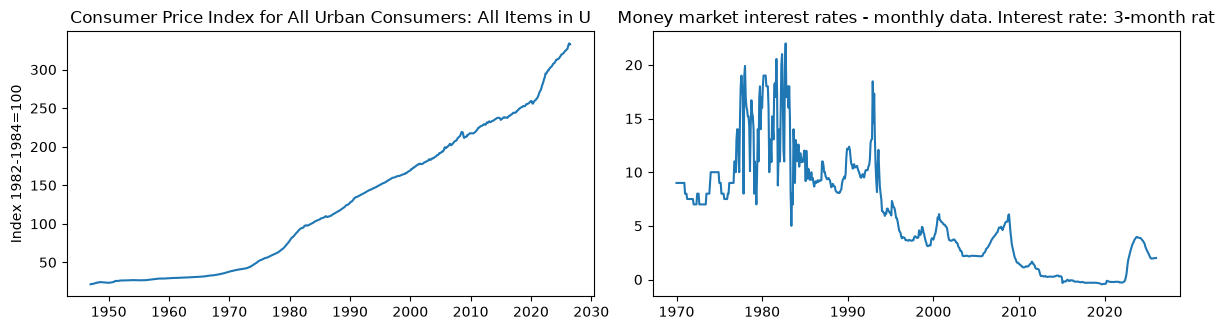

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot(cpi["dates"], cpi["values"]); axes[0].set_title(cpi["title"][:60]); axes[0].set_ylabel(cpi["units"])
eu = series.filter(pl.col("source_id") == "irt_st_m:M.IRT_M3.DK").collect().row(0, named=True)
axes[1].plot(eu["dates"], eu["values"]); axes[1].set_title(eu["description"][:70]); axes[1].set_ylabel(eu["units"] or "")
plt.tight_layout(); plt.show()

In [15]:
series.head()

In [13]:
# the dimensions column keeps id, human name, code and label for every SDMX dimension
pl.DataFrame(eu["dimensions"])

id,name,code,label
str,str,str,str
"""freq""","""Time frequency""","""M""","""Monthly"""
"""int_rt""","""Interest rate""","""IRT_M3""","""3-month rate"""
"""geo""","""Geopolitical entity (reporting)""","""DK""","""Denmark"""


## 5. Ask questions across everything with DuckDB

Any SQL engine that reads Parquet sees the series tree as one table.

In [14]:
tree = (data_dir() / "series").as_posix()
duckdb.sql(f"select source, frequency, license_id, origin_us_federal, count(*) as series, sum(n_obs) as observations "
           f"from '{tree}/**/*.parquet' group by all order by all").pl()

source,frequency,license_id,origin_us_federal,series,observations
str,str,str,bool,i64,"decimal[38,0]"
"""eurostat""","""A""","""eurostat-reuse""",null,9052,45117
"""eurostat""","""M""","""eurostat-reuse""",null,64,21218
"""eurostat""","""Q""","""eurostat-reuse""",null,20146,20146
"""fred""","""A""","""fred-copyrighted-citation-required""",false,418,3808
"""fred""","""A""","""fred-public-domain-citation-requested""",true,650,21221
"""fred""","""M""","""fred-public-domain-citation-requested""",true,2142,1002749
"""fred""","""S""","""fred-public-domain-citation-requested""",true,1817,126750
"""oecd""","""A""","""oecd-terms""",null,1665,36760


## 6. Licences are columns, not footnotes

Every row carries `license_id`, `license_url`, the exact `attribution` the source asks for, and
`license_notes` with the caveats. For a snapshot that can be shared and used for training, the
defensible selection is: everything from Eurostat and OECD, plus FRED series that are both
`fred-public-domain-citation-requested` **and** from a US federal source (`origin_us_federal`).

In [15]:
series.group_by("license_id", "origin_us_federal").agg(pl.len().alias("series")).sort("license_id").collect()

license_id,origin_us_federal,series
str,bool,u32
"""eurostat-reuse""",null,29262
"""fred-copyrighted-citation-required""",false,418
"""fred-public-domain-citation-requested""",true,4609
"""oecd-terms""",null,1665


## 7. A training snapshot: fixed-size shuffled shards

For model training the per-dataset files are the wrong shape (thousands of small files, grouped by
dataset). `export_shards` repacks the selection into shards of a target size (128 MB by default; 1 MB
here so the example makes several), assigns every series to a random shard, shuffles inside each shard,
casts `values` to float32, and writes an `index.parquet` and a `manifest.json`. A training loop reads
one shard at a time, so memory stays flat on a laptop, and every batch is a mix of sources and datasets.

Command line: `terrastat export my_snapshot --public-only --min-obs 24 --target-mb 128`.

In [16]:
manifest = export_shards("getting_started", public_only=True, min_obs=12, target_mb=1, seed=0)
print({k: manifest[k] for k in ("n_shards", "rows", "bytes")})
print(manifest["counts"]["source"], manifest["counts"]["frequency"])
pl.DataFrame(manifest["shards"])

{'n_shards': 4, 'rows': 6291, 'bytes': 3737556}
{'eurostat': 356, 'oecd': 1357, 'fred': 4578} {'A': 2268, 'M': 2206, 'S': 1817}


file,rows,bytes
str,i64,i64
"""shard-00000.parquet""",1578,921788
"""shard-00001.parquet""",1574,941958
"""shard-00002.parquet""",1546,907994
"""shard-00003.parquet""",1593,965816


In [17]:
import numpy as np

def windows(batch, context=24, horizon=12, max_per_series=4, rng=np.random.default_rng(0)):
    # random (context, horizon) windows from a batch of series -> two float32 arrays
    X, Y = [], []
    for vals in batch["values"].to_list():
        v = np.asarray(vals, dtype=np.float32)
        v = v[~np.isnan(v)]
        if len(v) < context + horizon:
            continue
        for start in rng.integers(0, len(v) - context - horizon + 1, size=max_per_series):
            X.append(v[start:start + context]); Y.append(v[start + context:start + context + horizon])
    return (np.stack(X) if X else np.empty((0, context))), (np.stack(Y) if Y else np.empty((0, horizon)))

n_batches = 0
for batch in iter_shard_batches("getting_started", batch_rows=256, columns=["series_uid", "frequency", "values"], seed=0):
    X, Y = windows(batch)
    n_batches += 1
    if n_batches <= 3:
        print(f"batch {n_batches}: {batch.height} series -> X {X.shape}, Y {Y.shape}")
print("batches:", n_batches)

batch 1: 256 series -> X (644, 24), Y (644, 12)
batch 2: 256 series -> X (692, 24), Y (692, 12)
batch 3: 256 series -> X (604, 24), Y (604, 12)


batches: 28


## 8. Running the real thing

One command fetches everything from every source at every frequency, tidies it, builds the series view,
and keeps track of progress itself. Run it from a terminal in the `terrastat` folder, stop it with Ctrl+C
whenever you need the machine, and run it again to continue:

```
.\.venv\Scripts\terrastat run                  # everything; re-run until it reports 0 remaining
.\.venv\Scripts\terrastat run --max-hours 8    # or stop by itself after 8 hours
.\.venv\Scripts\terrastat status eurostat      # where things stand
.\.venv\Scripts\terrastat export public_v1 --public-only --min-obs 24 --target-mb 128
```

FRED takes a few hours, OECD about a day, Eurostat several days (it generates each bulk file on request at
about 24 KB/s). Re-run this notebook afterwards: sections 3 to 7 will show the full data instead of the samples.